<h1 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
EDA Airbnb New York 📅2019
</h1>

<h2 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Analisis de un dataset de Airbnb en Nueva York correspondiente al año 📅2019.
<br>Analisis y limpieza EDA del data set para detectar posibles problemas en los datos y prepararlo para modelado.
</h2>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">1. Librerias</span>
</h3>

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">2. Configuracion basica</span>
<br>Ajuste general para ver mejor las tablas y los graficos durante el analisis.
</h3>

In [3]:
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">3. Carga del dataset</span>
</h3>

In [4]:
data_path = os.path.join("..", "data", "raw", "AB_NYC_2019.csv")
df = pd.read_csv(data_path)

df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">4. Inspeccion inicial</span>
<br>Antes de analizar los datos en detalle, reviso el tamaño del dataset, los nombres de las columnas y los tipos de datos. Para entender mejor con que informacion voy a trabajar.
</h3>

In [5]:
df.shape

(48895, 16)

In [6]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Se observa una mezcla de variables numericas y categoricas, y ya empiezan a verse algunas columnas con valores nulos que hay que revisar con mas detalle.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">5. Valores nulos y duplicados</span>
<br>Reviso si hay valores faltantes o filas duplicadas dentro del dataset. Esto es importante porque estos problemas pueden afectar el analisis y tambien el rendimiento de un futuro modelo.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Valores nulos:
</h3>

In [9]:
df.isnull().sum().sort_values(ascending=False)

last_review                       10052
reviews_per_month                 10052
host_name                            21
name                                 16
neighbourhood_group                   0
neighbourhood                         0
id                                    0
host_id                               0
longitude                             0
latitude                              0
room_type                             0
price                                 0
number_of_reviews                     0
minimum_nights                        0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Porcentaje de nulos:
</h3>

In [10]:
(df.isnull().mean() * 100).sort_values(ascending=False)

last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.000000
host_id                            0.000000
longitude                          0.000000
latitude                           0.000000
room_type                          0.000000
price                              0.000000
number_of_reviews                  0.000000
minimum_nights                     0.000000
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Duplicados:
</h3>

In [11]:
df.duplicated().sum()

np.int64(0)

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Verificamos si <span style="color:#ff5733;">id</span> esta duplicado:


</h3>

In [12]:
df["id"].duplicated().sum()

np.int64(0)

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Despues de revisar los valores nulos, se observa que las columnas <span style="color:#ff5733;">last_review</span> y <span style="color:#ff5733;">reviews_per_month</span> son las que concentran la mayor cantidad de datos faltantes. Esto podria estar relacionado con alojamientos que no han recibido reseñas. Por otro lado, no parecen existir duplicados exactos en el dataset, y la columna <span style="color:#ff5733;">id</span> mantiene valores unicos.

</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">6. Tipos de variables</span>
<br>Separo las variables numericas y categoricas para entender mejor la estructura del dataset y organizar mejor el analisis.
</h3>

In [13]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Variables categoricas:")
print(cat_cols)

print("\nVariables numericas:")
print(num_cols)

Variables categoricas:
['name', 'host_name', 'neighbourhood_group', 'neighbourhood', 'room_type', 'last_review']

Variables numericas:
['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Al separar las variables del dataset, se observa que hay una combinacion de columnas numericas y categoricas. Esta division sera util en los siguientes pasos, ya que no todas las variables se analizan de la misma forma.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">7. Analisis de variables categoricas</span>
<br>En esta parte reviso algunas variables categoricas del dataset para entender mejor como se distribuyen los alojamientos segun zona y tipo de habitacion.
</h3>

In [14]:
df["neighbourhood_group"].value_counts()

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

In [15]:
df["room_type"].value_counts()

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

In [16]:
df["neighbourhood"].value_counts().head(10)

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Interpretacion 📈grafica:
</h3>

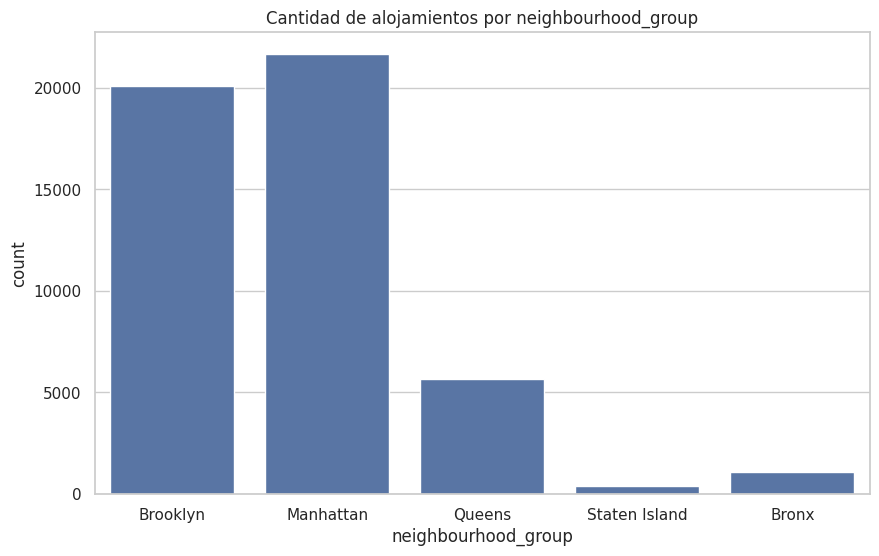

In [17]:
sns.countplot(data=df, x="neighbourhood_group")
plt.title("Cantidad de alojamientos por neighbourhood_group")
plt.show()

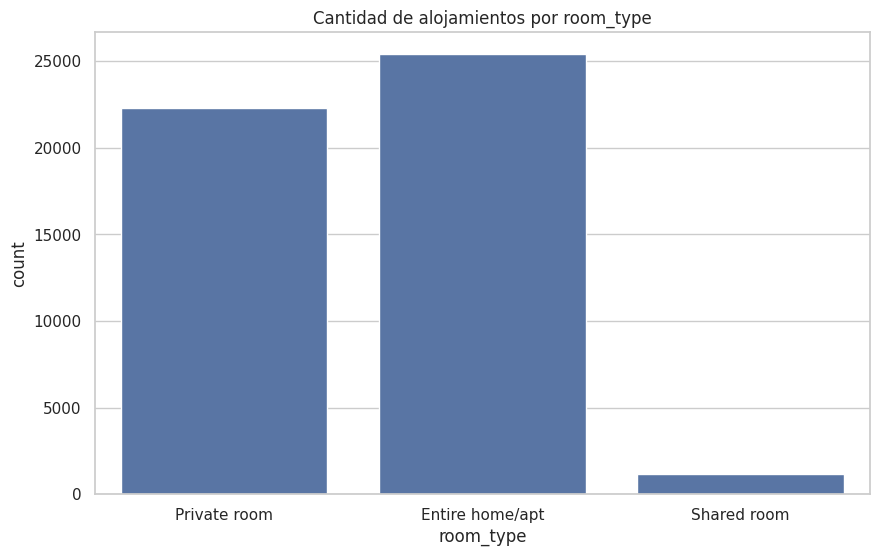

In [18]:
sns.countplot(data=df, x="room_type")
plt.title("Cantidad de alojamientos por room_type")
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Al revisar las variables categoricas principales, se observa que los alojamientos no estan distribuidos de forma uniforme. Algunas zonas concentran mucha mas oferta que otras, y ciertos tipos de habitacion aparecen con mucha mas frecuencia dentro del dataset.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">8. Analisis de variables numericas</span>
<br>En esta parte reviso las variables numericas del dataset para entender mejor su comportamiento, detectar valores extremos y observar si algunas distribuciones estan muy sesgadas.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Resumen estadistico:
</h3>

In [19]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
id,48895.0,1.901714e+07,1.098311e+07,2539.00000,9.471945e+06,1.967728e+07,2.915218e+07,3.648724e+07
host_id,48895.0,6.762001e+07,7.861097e+07,2438.00000,7.822033e+06,3.079382e+07,1.074344e+08,2.743213e+08
latitude,48895.0,4.072895e+01,5.453008e-02,40.49979,4.069010e+01,4.072307e+01,4.076311e+01,4.091306e+01
longitude,48895.0,-7.395217e+01,4.615674e-02,-74.24442,-7.398307e+01,-7.395568e+01,-7.393627e+01,-7.371299e+01
price,48895.0,1.527207e+02,2.401542e+02,0.00000,6.900000e+01,1.060000e+02,1.750000e+02,1.000000e+04
minimum_nights,48895.0,7.029962e+00,2.051055e+01,1.00000,1.000000e+00,3.000000e+00,5.000000e+00,1.250000e+03
number_of_reviews,48895.0,2.327447e+01,4.455058e+01,0.00000,1.000000e+00,5.000000e+00,2.400000e+01,6.290000e+02
reviews_per_month,38843.0,1.373221e+00,1.680442e+00,0.01000,1.900000e-01,7.200000e-01,2.020000e+00,5.850000e+01
calculated_host_listings_count,48895.0,7.143982e+00,3.295252e+01,1.00000,1.000000e+00,1.000000e+00,2.000000e+00,3.270000e+02
availability_365,48895.0,1.127813e+02,1.316223e+02,0.00000,0.000000e+00,4.500000e+01,2.270000e+02,3.650000e+02


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
📈Histogramas de variables clave:
</h3>

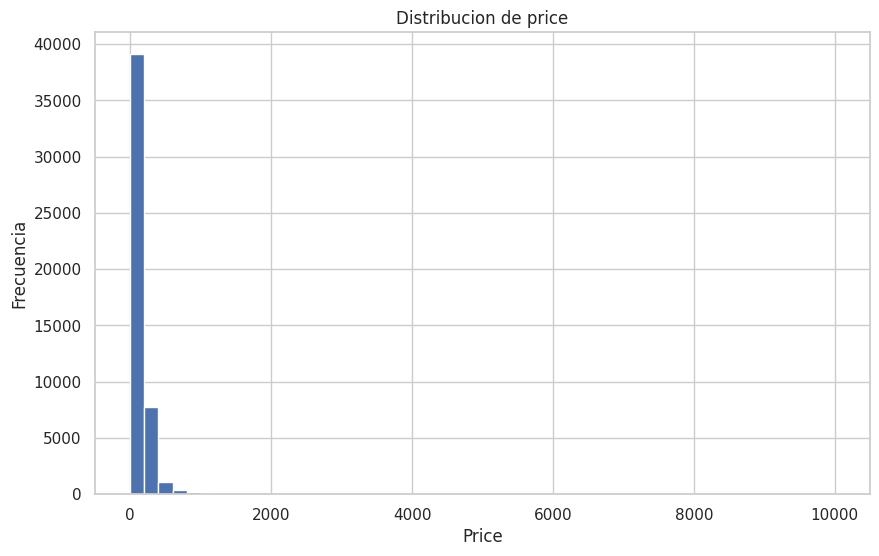

In [20]:
df["price"].hist(bins=50)
plt.title("Distribucion de price")
plt.xlabel("Price")
plt.ylabel("Frecuencia")
plt.show()

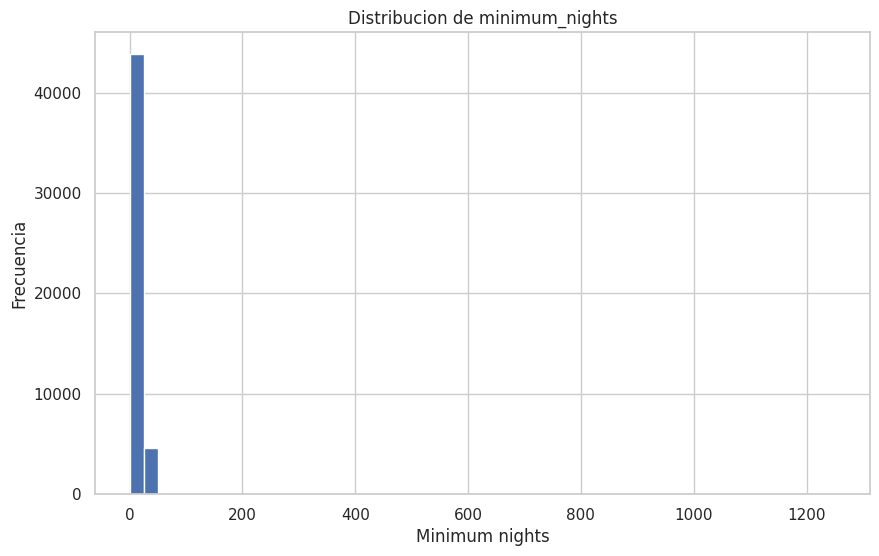

In [21]:
df["minimum_nights"].hist(bins=50)
plt.title("Distribucion de minimum_nights")
plt.xlabel("Minimum nights")
plt.ylabel("Frecuencia")
plt.show()

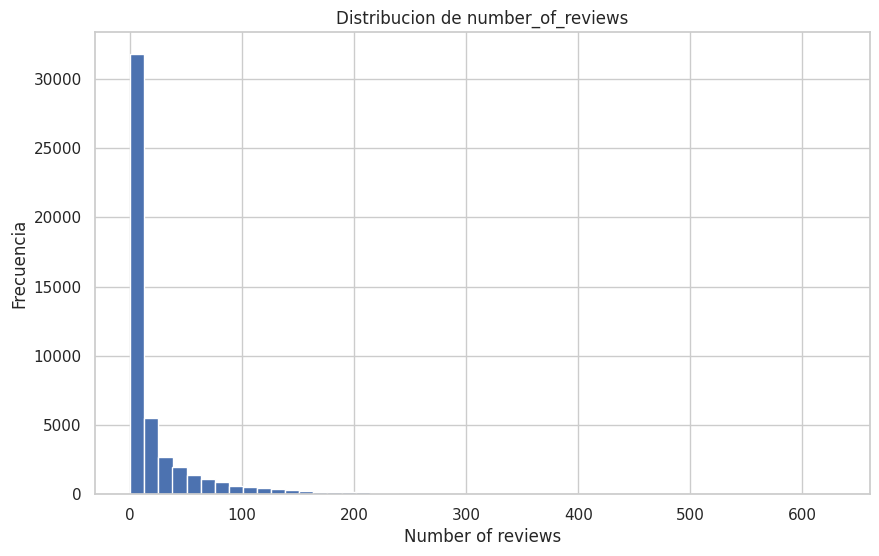

In [22]:
df["number_of_reviews"].hist(bins=50)
plt.title("Distribucion de number_of_reviews")
plt.xlabel("Number of reviews")
plt.ylabel("Frecuencia")
plt.show()

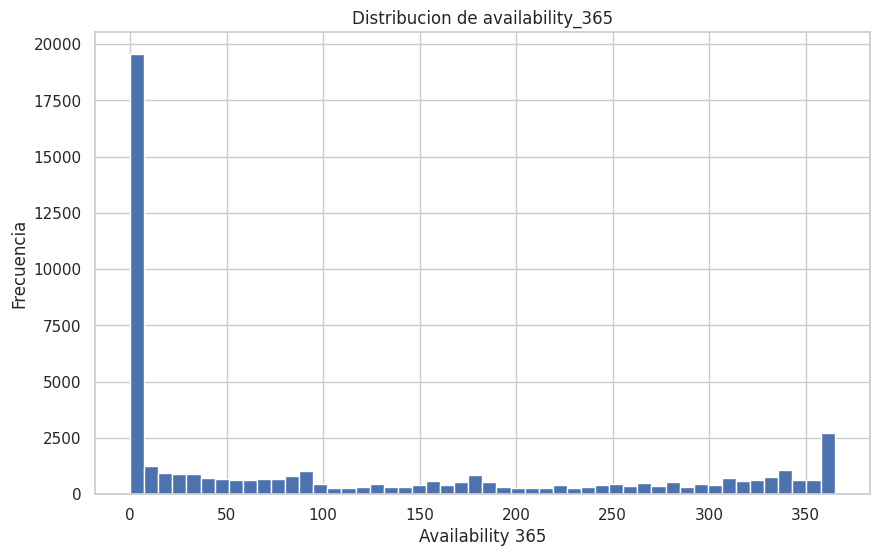

In [23]:
df["availability_365"].hist(bins=50)
plt.title("Distribucion de availability_365")
plt.xlabel("Availability 365")
plt.ylabel("Frecuencia")
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
📈Boxplots para detectar outliers:
</h3>

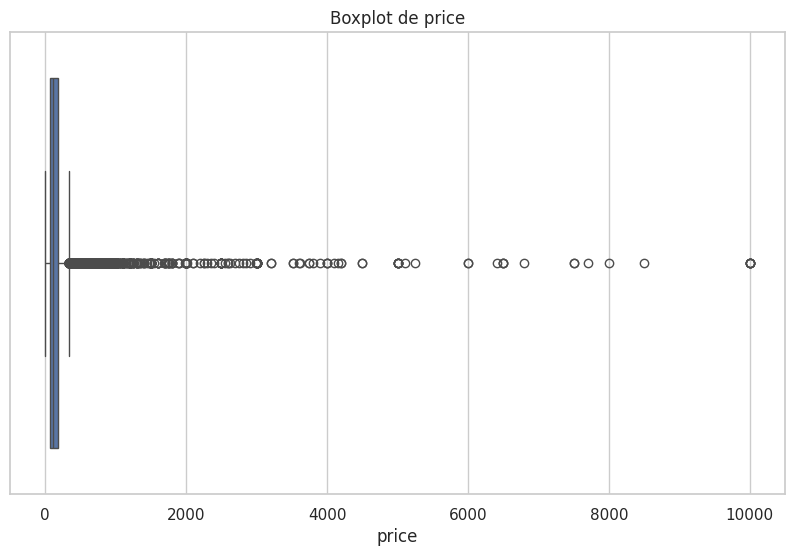

In [24]:
sns.boxplot(x=df["price"])
plt.title("Boxplot de price")
plt.show()

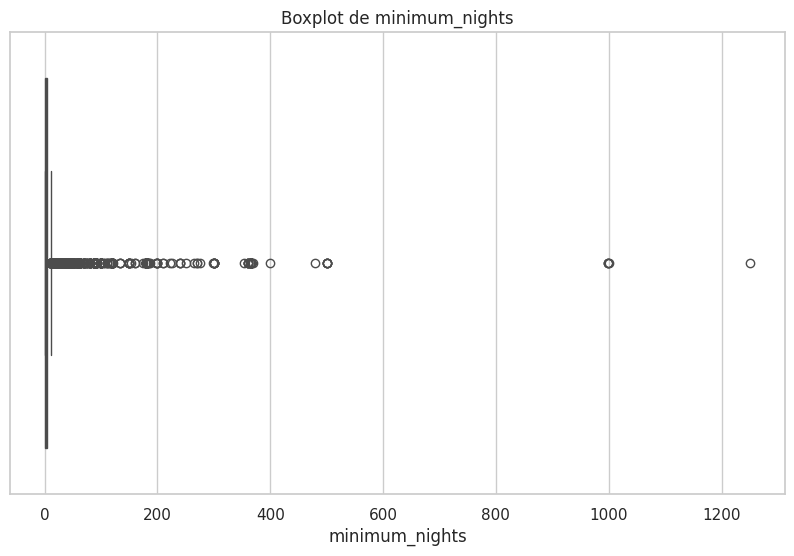

In [25]:
sns.boxplot(x=df["minimum_nights"])
plt.title("Boxplot de minimum_nights")
plt.show()

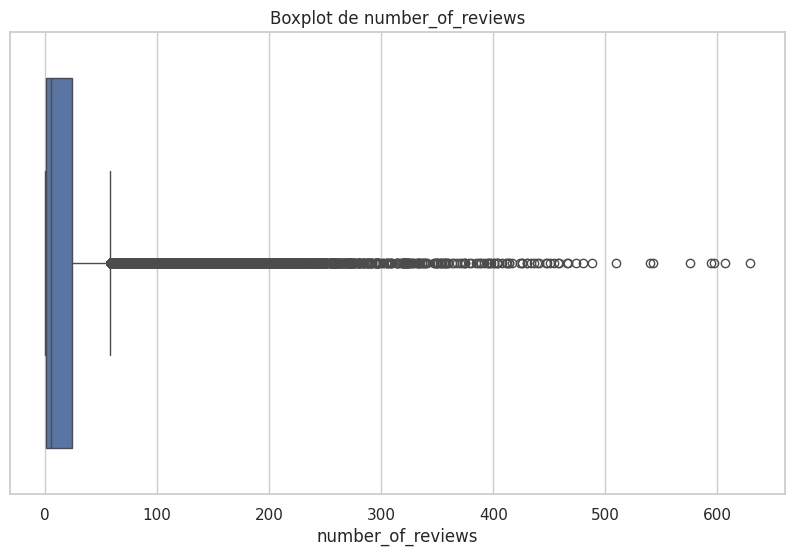

In [26]:
sns.boxplot(x=df["number_of_reviews"])
plt.title("Boxplot de number_of_reviews")
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Al revisar las variables numericas, se observa que varias de ellas no siguen una distribucion equilibrada. En especial, <span style="color:#ff5733;">price</span> y <span style="color:#ff5733;">minimum_nights</span> presentan una fuerte concentracion de valores bajos junto con algunos valores extremos muy altos. Esto sugiere la presencia de outliers y sera importante tenerlo en cuenta en los siguientes pasos del analisis.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">9. Relacion de price con otras variables</span>
<br>En esta parte analizo 📈graficamente como cambia el precio segun algunas variables del dataset. Esto ayuda a detectar patrones utiles y a entender que factores podrian estar influyendo mas en el valor de un alojamiento.
</h3>

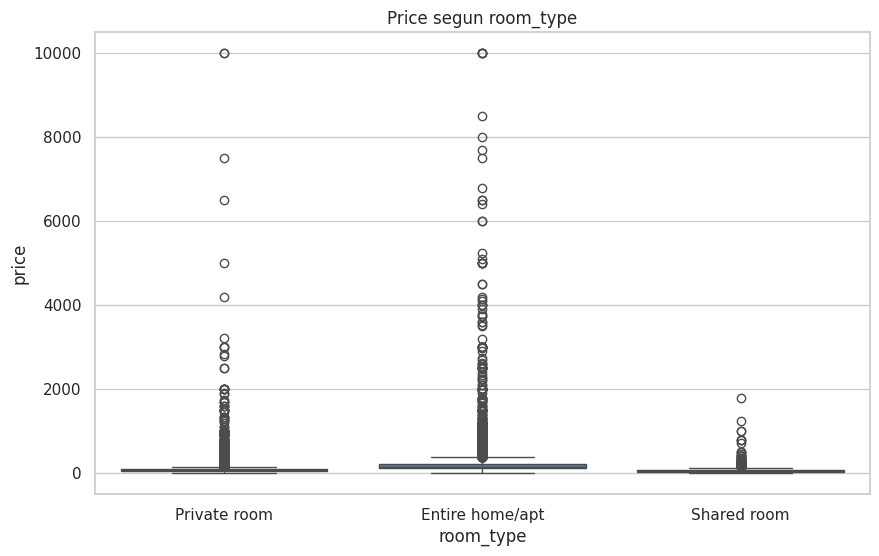

In [27]:
sns.boxplot(data=df, x="room_type", y="price")
plt.title("Price segun room_type")
plt.show()

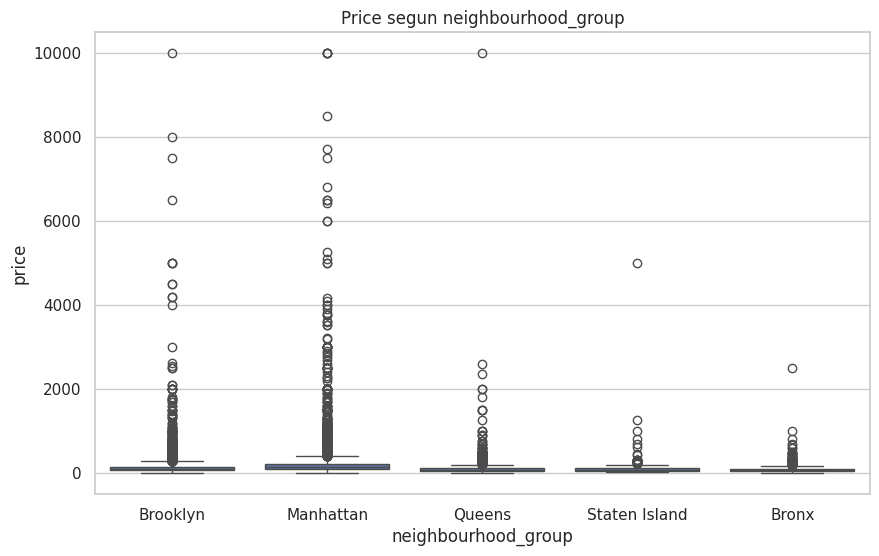

In [28]:
sns.boxplot(data=df, x="neighbourhood_group", y="price")
plt.title("Price segun neighbourhood_group")
plt.show()

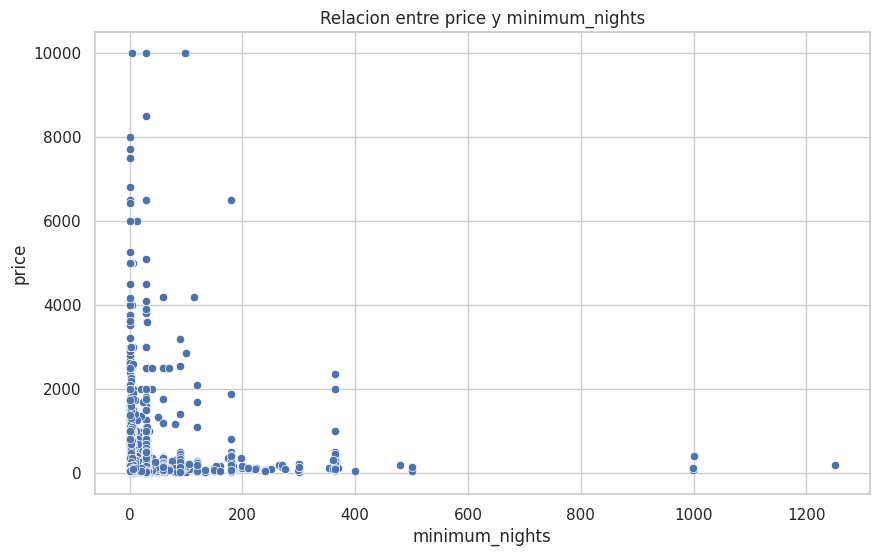

In [29]:
sns.scatterplot(data=df, x="minimum_nights", y="price")
plt.title("Relacion entre price y minimum_nights")
plt.show()

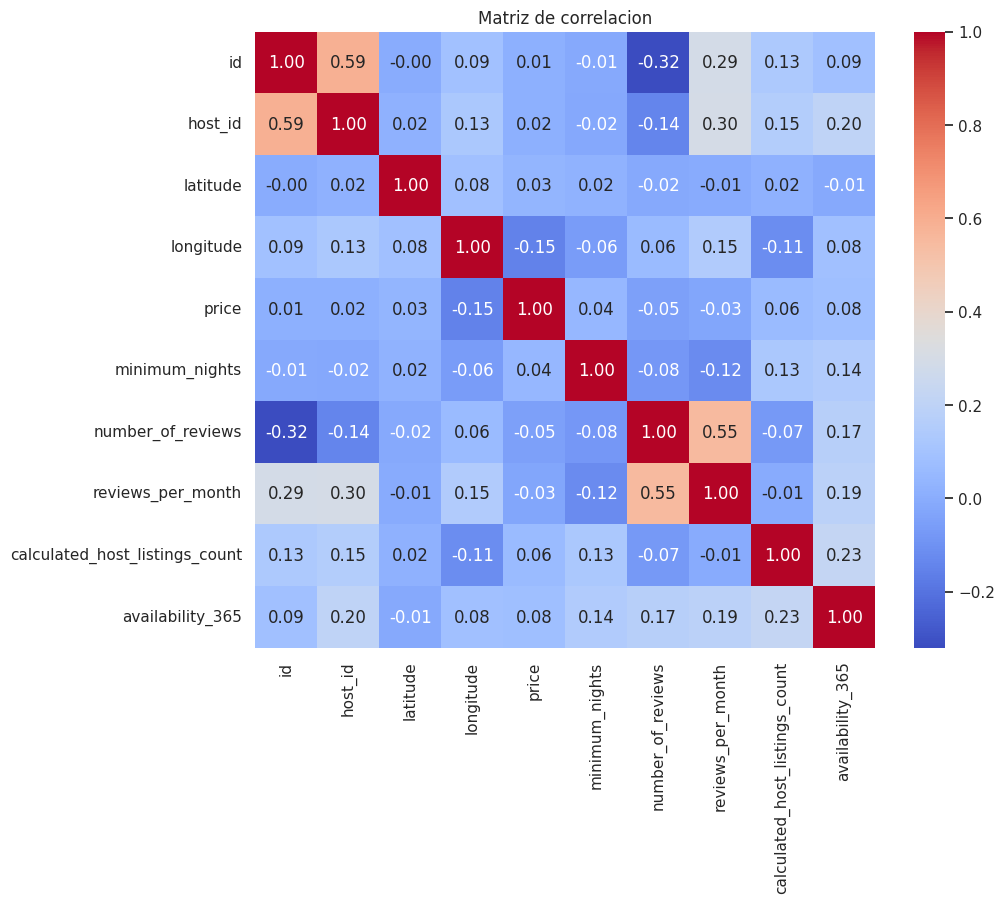

In [30]:
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlacion")
plt.show()

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Al comparar <span style="color:#ff5733;">price</span> con otras variables, se observan diferencias claras segun el tipo de habitacion y la zona del alojamiento. Esto sugiere que variables como <span style="color:#ff5733;">room_type</span> y <span style="color:#ff5733;">neighbourhood_group</span> podrian tener un papel importante a la hora de explicar el precio. En cambio, con algunas variables numericas la relacion no parece tan clara a simple vista, en parte por la presencia de valores extremos.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">10. Revision de outliers</span>
<br>En esta parte reviso algunas variables que parecen tener valores extremos. Esto es importante porque esos datos pueden afectar tanto el analisis como el comportamiento del modelo final.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Resumen con percentiles:
</h3>

In [31]:
df[["price", "minimum_nights", "calculated_host_listings_count"]].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).T

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
price,48895.0,152.720687,240.154170,0.0,69.0,106.0,175.0,269.0,355.0,799.0,10000.0
minimum_nights,48895.0,7.029962,20.510550,1.0,1.0,3.0,5.0,28.0,30.0,45.0,1250.0
calculated_host_listings_count,48895.0,7.143982,32.952519,1.0,1.0,1.0,2.0,5.0,15.0,232.0,327.0


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Ver los precios mas altos:
</h3>

In [32]:
df.sort_values("price", ascending=False).head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
17692,13894339,Luxury 1 bedroom apt. -stunning Manhattan views,5143901,Erin,Brooklyn,Greenpoint,40.73260,-73.95739,Entire home/apt,10000,5,5,2017-07-27,0.16,1,0
29238,22436899,1-BR Lincoln Center,72390391,Jelena,Manhattan,Upper West Side,40.77213,-73.98665,Entire home/apt,10000,30,0,NaN,NaN,1,83
9151,7003697,Furnished room in Astoria apartment,20582832,Kathrine,Queens,Astoria,40.76810,-73.91651,Private room,10000,100,2,2016-02-13,0.04,1,0
6530,4737930,Spanish Harlem Apt,1235070,Olson,Manhattan,East Harlem,40.79264,-73.93898,Entire home/apt,9999,5,1,2015-01-02,0.02,1,0
40433,31340283,2br - The Heart of NYC: Manhattans Lower East ...,4382127,Matt,Manhattan,Lower East Side,40.71980,-73.98566,Entire home/apt,9999,30,0,NaN,NaN,1,365
12342,9528920,"Quiet, Clean, Lit @ LES & Chinatown",3906464,Amy,Manhattan,Lower East Side,40.71355,-73.98507,Private room,9999,99,6,2016-01-01,0.14,1,83
30268,23377410,Beautiful/Spacious 1 bed luxury flat-TriBeCa/Soho,18128455,Rum,Manhattan,Tribeca,40.72197,-74.00633,Entire home/apt,8500,30,2,2018-09-18,0.18,1,251
4377,2953058,Film Location,1177497,Jessica,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,2016-09-15,0.03,11,365
29662,22779726,East 72nd Townhouse by (Hidden by Airbnb),156158778,Sally,Manhattan,Upper East Side,40.76824,-73.95989,Entire home/apt,7703,1,0,NaN,NaN,12,146
42523,33007610,70' Luxury MotorYacht on the Hudson,7407743,Jack,Manhattan,Battery Park City,40.71162,-74.01693,Entire home/apt,7500,1,0,NaN,NaN,1,364


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Ver los minimum_nights mas altos:
</h3>

In [33]:
df.sort_values("minimum_nights", ascending=False).head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
5767,4204302,Prime W. Village location 1 bdrm,17550546,Genevieve,Manhattan,Greenwich Village,40.73293,-73.99782,Entire home/apt,180,1250,2,2014-11-09,0.03,1,365
2854,1615764,NaN,6676776,Peter,Manhattan,Battery Park City,40.71239,-74.01620,Entire home/apt,400,1000,0,NaN,NaN,1,362
26341,20990053,Beautiful place in Brooklyn! #2,151084261,Angie,Brooklyn,Williamsburg,40.71772,-73.95059,Private room,79,999,24,2018-06-28,1.12,6,249
13404,10053943,Historic Designer 2 Bed. Apartment,2697686,Glenn H.,Manhattan,Harlem,40.82915,-73.94034,Entire home/apt,99,999,2,2018-01-04,0.07,1,42
38664,30378211,Shared Studio (females only),200401254,Meg,Manhattan,Greenwich Village,40.73094,-73.99900,Shared room,110,999,0,NaN,NaN,1,365
11193,8668115,Zen Room in Crown Heights Brooklyn,8996336,Laura,Brooklyn,Crown Heights,40.67255,-73.94914,Private room,50,500,10,2016-09-22,0.22,1,365
47620,35834935,Williamsburg Apartment,82674375,Meg,Brooklyn,Williamsburg,40.70898,-73.94885,Entire home/apt,140,500,0,NaN,NaN,1,331
8014,6169897,Wonderful Large 1 bedroom,10720264,John,Manhattan,Harlem,40.82135,-73.95521,Entire home/apt,75,500,0,NaN,NaN,1,362
14285,11096888,Peaceful apartment close to F/G,2228137,Amanda,Brooklyn,Kensington,40.64779,-73.97956,Private room,45,500,0,NaN,NaN,1,358
7355,5431845,Beautiful Fully Furnished 1 bed/bth,3680008,Aliya,Queens,Long Island City,40.75104,-73.93863,Entire home/apt,134,500,30,2018-06-24,0.57,1,90


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Ver los hosts con mas listings:
</h3>

In [34]:
df.sort_values("calculated_host_listings_count", ascending=False).head(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
41990,32634874,Sonder | Stock Exchange | Pristine 1BR + Sofa Bed,219517861,Sonder (NYC),Manhattan,Financial District,40.70604,-74.01216,Entire home/apt,248,2,7,2019-06-26,2.59,327,294
42169,32740310,Sonder | The Nash | Warm Studio + Grilling Area,219517861,Sonder (NYC),Manhattan,Murray Hill,40.74928,-73.97453,Entire home/apt,262,2,9,2019-06-23,2.35,327,113
41934,32590792,Sonder | The Nash | Original 1BR + Rooftop,219517861,Sonder (NYC),Manhattan,Murray Hill,40.74763,-73.97524,Entire home/apt,316,2,5,2019-06-16,1.17,327,76
42031,32662408,Dashing 1BR in Midtown East by Sonder,219517861,Sonder (NYC),Manhattan,Murray Hill,40.74422,-73.97309,Entire home/apt,174,29,0,NaN,NaN,327,312
41995,32635717,Sonder | Stock Exchange | Calming 1BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70570,-74.01221,Entire home/apt,230,2,6,2019-06-10,1.98,327,297
41404,32237138,Sonder | Stock Exchange | Lively Studio + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70714,-74.01225,Entire home/apt,203,2,7,2019-06-24,1.88,327,338
41375,32224165,Sonder | Stock Exchange | Modern 2BR + Lounge,219517861,Sonder (NYC),Manhattan,Financial District,40.70621,-74.01238,Entire home/apt,425,2,8,2019-05-27,2.11,327,339
41373,32223317,Sonder | Stock Exchange | Premier 2BR + Laundry,219517861,Sonder (NYC),Manhattan,Financial District,40.70580,-74.01210,Entire home/apt,404,2,10,2019-05-27,2.26,327,330
41374,32223854,Sonder | Stock Exchange | Classic 1BR + Kitchen,219517861,Sonder (NYC),Manhattan,Financial District,40.70641,-74.01047,Entire home/apt,234,2,2,2019-06-04,1.46,327,332
41362,32218558,Sonder | Stock Exchange | Welcoming 1BR + Sofa...,219517861,Sonder (NYC),Manhattan,Financial District,40.70584,-74.01060,Entire home/apt,245,2,6,2019-05-19,1.65,327,272


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Al revisar con mas detalle algunas variables, se confirma la presencia de valores extremos, sobre todo en <span style="color:#ff5733;">price</span> y <span style="color:#ff5733;">minimum_nights</span>. Aunque estos casos no necesariamente son errores, si representan situaciones poco comunes dentro del dataset y conviene tenerlos en cuenta al interpretar los resultados.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">11. Seleccion de variables</span>
<br>En esta parte reviso que columnas tiene sentido conservar y cuales no aportan demasiado para este proyecto. La idea es quedarme con variables mas utiles para un posible modelo y dejar fuera columnas que funcionan mas como identificadores o texto libre.
</h3>

In [35]:
df_clean = df.copy()
columns_to_drop = ["id", "host_id", "name", "host_name", "last_review"]
df_clean = df_clean.drop(columns=columns_to_drop)
df_clean.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365
3,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
espues de revisar el contenido de las columnas, decidi eliminar algunas variables que no parecen aportar demasiado valor para este proyecto, como identificadores y texto libre. Con esto, el dataset queda mas simple, mas limpio y mas enfocado en variables que si pueden ser utiles para analizar o modelar el precio.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">12. Tratamiento de valores nulos</span>
<br>Despues de eliminar algunas columnas, vuelvo a revisar los valores nulos para decidir como tratarlos en el dataset limpio. La idea es aplicar una solucion simple y coherente con el contexto de los datos.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Revisar nulos en el dataset limpio:
</h3>

In [36]:
df_clean.isnull().sum().sort_values(ascending=False)

reviews_per_month                 10052
neighbourhood                         0
neighbourhood_group                   0
latitude                              0
longitude                             0
price                                 0
room_type                             0
minimum_nights                        0
number_of_reviews                     0
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Rellenar reviews_per_month con cero (0):
</h3>

In [37]:
df_clean["reviews_per_month"] = df_clean["reviews_per_month"].fillna(0)

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Comprobar que ya no quedan nulos:
</h3>

In [38]:
df_clean.isnull().sum()

neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Despues de limpiar algunas columnas, el principal valor nulo que quedaba estaba en <span style="color:#ff5733;">reviews_per_month</span>. En este caso, decidi completarlo con <span style="color:#ff5733;">0</span>, ya que puede interpretarse como alojamientos sin actividad de reseñas mensuales. Con esto, el dataset queda sin valores faltantes y listo para los siguientes pasos.

</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">13. Preparacion del dataset para modelado</span>
<br>En esta parte dejo el dataset listo para un posible modelo de Machine Learning. Primero separo la variable objetivo y despues convierto las variables categoricas en variables numericas para poder trabajar con ellas mas adelante.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Separar variable objetivo y variables explicativas:
</h3>

In [39]:
X = df_clean.drop(columns=["price"])
y = df_clean["price"]

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Convertir variables categoricas con get_dummies():
</h3>

In [40]:
X = pd.get_dummies(X, drop_first=True, dtype=int)

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Como quedo X:
</h3>

In [41]:
X.head()

,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island,neighbourhood_Arden Heights,neighbourhood_Arrochar,neighbourhood_Arverne,neighbourhood_Astoria,neighbourhood_Bath Beach,neighbourhood_Battery Park City,neighbourhood_Bay Ridge,neighbourhood_Bay Terrace,"neighbourhood_Bay Terrace, Staten Island",neighbourhood_Baychester,neighbourhood_Bayside,neighbourhood_Bayswater,neighbourhood_Bedford-Stuyvesant,neighbourhood_Belle Harbor,neighbourhood_Bellerose,neighbourhood_Belmont,neighbourhood_Bensonhurst,neighbourhood_Bergen Beach,neighbourhood_Boerum Hill,neighbourhood_Borough Park,neighbourhood_Breezy Point,neighbourhood_Briarwood,neighbourhood_Brighton Beach,neighbourhood_Bronxdale,neighbourhood_Brooklyn Heights,neighbourhood_Brownsville,neighbourhood_Bull's Head,neighbourhood_Bushwick,neighbourhood_Cambria Heights,neighbourhood_Canarsie,neighbourhood_Carroll Gardens,neighbourhood_Castle Hill,neighbourhood_Castleton Corners,neighbourhood_Chelsea,neighbourhood_Chinatown,neighbourhood_City Island,neighbourhood_Civic Center,neighbourhood_Claremont Village,neighbourhood_Clason Point,neighbourhood_Clifton,neighbourhood_Clinton Hill,neighbourhood_Co-op City,neighbourhood_Cobble Hill,neighbourhood_College Point,neighbourhood_Columbia St,neighbourhood_Concord,neighbourhood_Concourse,neighbourhood_Concourse Village,neighbourhood_Coney Island,neighbourhood_Corona,neighbourhood_Crown Heights,neighbourhood_Cypress Hills,neighbourhood_DUMBO,neighbourhood_Ditmars Steinway,neighbourhood_Dongan Hills,neighbourhood_Douglaston,neighbourhood_Downtown Brooklyn,neighbourhood_Dyker Heights,neighbourhood_East Elmhurst,neighbourhood_East Flatbush,neighbourhood_East Harlem,neighbourhood_East Morrisania,neighbourhood_East New York,neighbourhood_East Village,neighbourhood_Eastchester,neighbourhood_Edenwald,neighbourhood_Edgemere,neighbourhood_Elmhurst,neighbourhood_Eltingville,neighbourhood_Emerson Hill,neighbourhood_Far Rockaway,neighbourhood_Fieldston,neighbourhood_Financial District,neighbourhood_Flatbush,neighbourhood_Flatiron District,neighbourhood_Flatlands,neighbourhood_Flushing,neighbourhood_Fordham,neighbourhood_Forest Hills,neighbourhood_Fort Greene,neighbourhood_Fort Hamilton,neighbourhood_Fort Wadsworth,neighbourhood_Fresh Meadows,neighbourhood_Glendale,neighbourhood_Gowanus,neighbourhood_Gramercy,neighbourhood_Graniteville,neighbourhood_Grant City,neighbourhood_Gravesend,neighbourhood_Great Kills,neighbourhood_Greenpoint,neighbourhood_Greenwich Village,neighbourhood_Grymes Hill,neighbourhood_Harlem,neighbourhood_Hell's Kitchen,neighbourhood_Highbridge,neighbourhood_Hollis,neighbourhood_Holliswood,neighbourhood_Howard Beach,neighbourhood_Howland Hook,neighbourhood_Huguenot,neighbourhood_Hunts Point,neighbourhood_Inwood,neighbourhood_Jackson Heights,neighbourhood_Jamaica,neighbourhood_Jamaica Estates,neighbourhood_Jamaica Hills,neighbourhood_Kensington,neighbourhood_Kew Gardens,neighbourhood_Kew Gardens Hills,neighbourhood_Kingsbridge,neighbourhood_Kips Bay,neighbourhood_Laurelton,neighbourhood_Lighthouse Hill,neighbourhood_Little Italy,neighbourhood_Little Neck,neighbourhood_Long Island City,neighbourhood_Longwood,neighbourhood_Lower East Side,neighbourhood_Manhattan Beach,neighbourhood_Marble Hill,neighbourhood_Mariners Harbor,neighbourhood_Maspeth,neighbourhood_Melrose,neighbourhood_Middle Village,neighbourhood_Midland Beach,neighbourhood_Midtown,neighbourhood_Midwood,neighbourhood_Mill Basin,neighbourhood_Morningside Heights,neighbourhood_Morris Heights,neighbourhood_Morris Park,neighbourhood_Morrisania,neighbourhood_Mott Haven,neighbourhood_Mount Eden,neighbourhood_Mount Hope,neighbourhood_Murray Hill,neighbourhood_Navy Yard,neighbourhood_Neponsit,neighbourhood_New Brighton,neighbourhood_New Dorp,neighbourhood_New Dorp Beach,neighbourhood_New Springville,neighb

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Ver el tamaño final de X e Y:
</h3>

In [42]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48895, 233)
y shape: (48895,)


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
En este paso se separo la variable objetivo <span style="color:#ff5733;">price</span> del resto del dataset y se transformaron las variables categoricas a formato numerico. Con esto, los datos quedan en una forma mucho mas util para trabajar en un futuro modelo.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">14. Division en train y test</span>
<br>En esta parte separo el dataset en entrenamiento y prueba para poder trabajar de una forma mas correcta y dejar los datos listos para el dodelo final.
</h3>

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [44]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (39116, 233)
X_test: (9779, 233)
y_train: (39116,)
y_test: (9779,)


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Despues de preparar las variables, dividi el dataset en entrenamiento y prueba. Con esto, los datos quedan organizados de una forma mas adecuada para continuar con un posible modelo mas adelante.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">15. Guardado de los datos procesados</span>
<br>En esta parte guardo los conjuntos de entrenamiento y prueba dentro de la carpeta <span style="color:#ff5733;">data/processed</span>. De esta forma, el proyecto queda mas ordenado y los datos ya preparados se pueden reutilizar mas adelante.
</h3>

In [45]:
processed_path = os.path.join("..", "data", "processed")
os.makedirs(processed_path, exist_ok=True)

In [46]:
X_train.to_csv(os.path.join(processed_path, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(processed_path, "X_test.csv"), index=False)
y_train.to_csv(os.path.join(processed_path, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(processed_path, "y_test.csv"), index=False)

In [47]:
print("Archivos guardados correctamente en data/processed")

Archivos guardados correctamente en data/processed


<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: center;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
Finalmente, guarde los conjuntos de entrenamiento y prueba en la carpeta <span style="color:#ff5733;">data/processed</span>. Con esto, el dataset queda listo para reutilizarse en un paso posterior de modelado sin necesidad de repetir toda la limpieza.
</h3>

<h3 style="
  color: #ffffff;
  background: linear-gradient(135deg, #0b0f12 0%, #2b3136 55%, #4a535a 100%);
  padding: 12px 16px;
  border-radius: 10px;
  text-align: justified;
  box-shadow: 0 10px 28px rgba(0,0,0,.18);
  border: 1px solid rgba(255,255,255,.10);
  border-top: 5px solid #22c55e;
">
<span style="color:#ff5733;">16. Conclusiones finales</span>
<br>- A lo largo de este analisis explore la estructura del dataset, revise valores nulos, duplicados, variables categoricas y variables numericas. Tambien identifique la presencia de valores extremos en columnas importantes como <span style="color:#ff5733;">price</span> y <span style="color:#ff5733;">minimum_nights</span>.
<br>- Despues de revisar el contenido del dataset, elimine algunas columnas que no aportaban demasiado para este proyecto y trate los valores nulos restantes de una forma simple. Finalmente, transforme las variables categoricas, separe el dataset en entrenamiento y prueba, y guarde los datos procesados para Machine Learning mas adelante.
<br>- En general, el dataset ofrece informacion util para estudiar el comportamiento de los alojamientos en Nueva York y deja una buena base para construir un modelo en un siguiente paso.
</h3>